<a href="https://colab.research.google.com/github/hynekmayrhofer1/Hynek-Mayrhofer/blob/main/osm.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
%pip install osmnx -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 104.4/104.4 kB 3.2 MB/s eta 0:00:00


In [2]:
import osmnx as ox
import networkx as nx
import matplotlib.pyplot as plt

# ── 1. GRAF Z OSM ──────────────────────────────────────────────────
G = ox.graph_from_place("Buštehrad, Czech Republic", network_type="walk",simplify=True) # zrusim multigraf

Délka: 603 m,  uzlů: 20


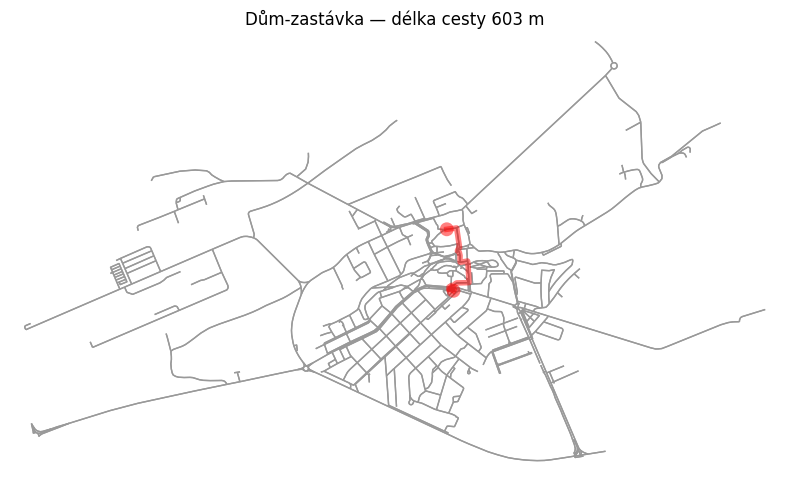

In [3]:
# ── 2. BELLMAN-FORD OD NULY ────────────────────────────────────────
def bellman_ford(graf, start, cil):
    uzly = list(graf.nodes)
    hrany = [(u, v, d["length"]) for u, v, d in graf.edges(data=True)]

    # Vzdálenosti — na začátku vše nekonečno
    dist = {u: float("inf") for u in uzly}
    dist[start] = 0
    odkud = {u: None for u in uzly}

    # Klíčová myšlenka: opakuj (počet uzlů - 1) krát
    for _ in range(len(uzly) - 1):
        zmenilo_se = False
        for u, v, vaha in hrany:          # projdi VŠECHNY hrany
            if dist[u] + vaha < dist[v]:  # lze zlepšit?
                dist[v] = dist[u] + vaha
                odkud[v] = u
                zmenilo_se = True
        if not zmenilo_se:
            break                         # hotovo dřív — optimalizace

    # Rekonstrukce cesty
    cesta, uzel = [], cil
    while uzel is not None:
        cesta.append(uzel)
        uzel = odkud[uzel]
    cesta.reverse()

    return dist[cil], cesta

# ── 3. SPUŠTĚNÍ ────────────────────────────────────────────────────
start_gps = (50.1574376, 14.1895563)  # Cesta od domu
cil_gps   = (50.154223, 14.189672)  # Marta a Míša
start = ox.nearest_nodes(G, X=start_gps[1], Y=start_gps[0])
cil   = ox.nearest_nodes(G, X=cil_gps[1],   Y=cil_gps[0])

delka, cesta = bellman_ford(G, start, cil)
print(f"Délka: {delka:.0f} m,  uzlů: {len(cesta)}")

# ── 4. VIZUALIZACE ─────────────────────────────────────────────────
fig, ax = ox.plot_graph_route(
    G, cesta,
    route_color="red", route_linewidth=4,
    node_size=0, bgcolor="white",
    show=False, close=False,
)
ax.set_title(f"Dům-zastávka — délka cesty {delka:.0f} m")
plt.tight_layout()
plt.savefig("bellman_ford.png", dpi=150, bbox_inches="tight")
plt.show()

Cesta je dlouhá 602.55 metrů.


/usr/local/lib/python3.12/dist-packages/osmnx/_validate.py:49: UserWarning: The attribute 'travel_time' is missing or null on some edges.
  _report_validation(is_valid, valid_msg, warn_msg, err_msg)


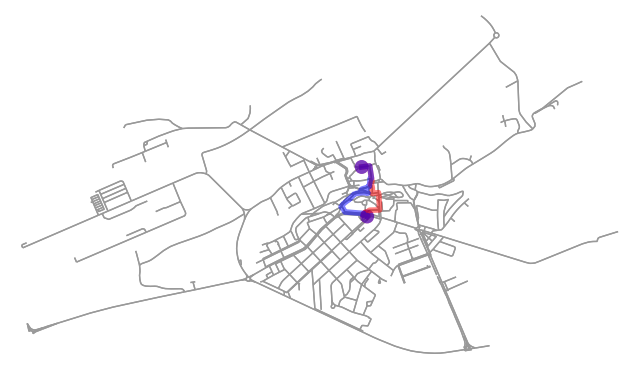

In [4]:
import networkx as nx

# Check if a path exists between start and cil
if nx.has_path(G, start, cil):
    try:
        cesta_delka = ox.shortest_path(G, start, cil, weight='length')
        delka_cesty = nx.shortest_path_length(G, start, cil, weight='length')
        print(f'Cesta je dlouhá {delka_cesty:.2f} metrů.')

        # Attempt to find path for 'travel_time'
        # This part might still warn about missing attributes, or raise NetworkXNoPath
        # if 'travel_time' is not consistently available or leads to a different disconnected component.
        cesta_cas = None # Initialize to None
        try:
            cesta_cas = ox.shortest_path(G, start, cil, weight='travel_time')
        except nx.NetworkXNoPath:
            print("Upozornění: Cesta pro 'travel_time' nebyla nalezena. Vizualizuji pouze cestu s váhou 'length'.")
        except Exception as e:
            print(f"Upozornění: Chyba při hledání cesty pro 'travel_time': {e}. Vizualizuji pouze cestu s váhou 'length'.")

        routes_to_plot = [cesta_delka]
        route_colors_to_plot = ["red"]
        route_linewidths_to_plot = [4]

        if cesta_cas is not None:
            routes_to_plot.append(cesta_cas)
            route_colors_to_plot.append("blue")
            route_linewidths_to_plot.append(4)

        ox.plot_graph_routes(
            G,
            routes=routes_to_plot,
            route_colors=route_colors_to_plot,
            route_linewidths=route_linewidths_to_plot,
            node_size=0,
            bgcolor="white",
        )

    except nx.NetworkXNoPath:
        print("Chyba: Nepodařilo se najít cestu mezi počátečním a cílovým uzlem pro zadanou váhu.")
        print("Zkontrolujte prosím, zda je graf souvislý a zda jsou uzly správně připojeny.")
    except Exception as e:
        print(f"Během výpočtu cesty nastala neočekávaná chyba: {e}")
else:
    print(f"Chyba: Nebyla nalezena žádná cesta mezi uzlem {start} a uzlem {cil} v grafu.")
    print("Doporučení: Zkontrolujte, zda jsou počáteční a cílové body ve stejné souvislé komponentě grafu, nebo zvažte rozšíření oblasti pro generování grafu.")

## Folium - Interaktivní mapa

In [5]:
import folium

# Initialize paths as empty lists if they don't exist, to prevent NameError
cesta_delka = globals().get('cesta_delka', [])
cesta_cas = globals().get('cesta_cas', [])

body_delka = []
if cesta_delka:
    body_delka = [(G.nodes[n]['y'], G.nodes[n]['x']) for n in cesta_delka]

body_cas = []
if cesta_cas:
    body_cas = [(G.nodes[n]['y'], G.nodes[n]['x']) for n in cesta_cas]

# Determine map center
mid_point = None
if body_delka:
    mid_point = body_delka[len(body_delka) // 2]
elif 'start_gps' in globals():
    mid_point = (start_gps[0], start_gps[1])
elif 'cil_gps' in globals():
    mid_point = (cil_gps[0], cil_gps[1])
else:
    mid_point = (50.0, 14.0) # Default for Czech Republic

m = folium.Map(location=mid_point, zoom_start=15, width="70%")

if body_delka:
    folium.PolyLine(body_delka, color="red",  weight=4, popup="Path by Length").add_to(m)
else:
    print("Warning: Length-based path not found or empty. Not plotting.")

if body_cas:
    folium.PolyLine(body_cas,   color="blue", weight=4, popup="Path by Travel Time").add_to(m)
else:
    print("Warning: Travel-time based path not found or empty. Not plotting.")

# Add markers for start and end, using GPS coords if paths are missing
start_coords = None
end_coords = None

if 'start_gps' in globals():
    start_coords = (start_gps[0], start_gps[1])
if 'cil_gps' in globals():
    end_coords = (cil_gps[0], cil_gps[1])

if start_coords:
    folium.Marker(start_coords, popup="Kaufland (Start)", icon=folium.Icon(color="green")).add_to(m)
if end_coords:
    folium.Marker(end_coords, popup="Marta a Míša (Cíl)",  icon=folium.Icon(color="red")).add_to(m)
else:
    print("Warning: Cannot place end marker without 'cil_gps'.")

m.save("cestyKladno.html") # content > sample_data
m